# AICE Associate 대비 실습 과정 — 4회차
## 데이터 전처리하기

> **과정 구성**: 총 8회 × 3시간, 실습 위주  
> **선수 학습**: 1~3회차. 3회차 EDA 에서 세운 가설(결측 대체, 이상치 처리, 요금제 인코딩)을 오늘 **실제 코드로 실행** 합니다.

### 전체 커리큘럼

| 회차 | 주제 | 핵심 키워드 |
|:---:|------|------------|
| 1 | AI/ML/DL 개요, 데이터 획득하기 | AI ⊃ ML ⊃ DL, 지도/비지도, `read_csv`, `read_excel`, `to_csv` |
| 2 | 데이터 구조 확인하기, 기초 데이터 다루기 | `info`, `describe`, `loc/iloc`, 필터링, 정렬, `groupby`, `merge` |
| 3 | 데이터 이해하기 (EDA) | 분포, 상관관계, `matplotlib`, `seaborn`, 가설 검증 |
| **4** | **데이터 전처리하기** | 결측치, 이상치, 구간화, 인코딩, 스케일링, `train_test_split` |
| 5 | AI 모델링 필수 개념, 지도학습 I | 과적합, 평가지표, 선형회귀, 로지스틱 회귀 |
| 6 | 지도학습 II | 의사결정나무, 앙상블, 랜덤포레스트, 그라디언트부스팅 |
| 7 | 인공신경망, 심층신경망, 딥러닝 프레임워크 | 퍼셉트론, 활성화함수, Keras `Sequential`, `EarlyStopping` |
| 8 | 비지도학습, 모델 성능 향상시키기 | K-Means, PCA, 교차검증, 하이퍼파라미터 튜닝, 모의고사 |

### 오늘의 학습 목표

1. 전처리가 왜 필요한지, 어떤 순서로 하는지 설명할 수 있다.
2. 결측치를 `dropna` / `fillna`(상수·평균·중앙값·최빈값·그룹별) 로 상황에 맞게 처리할 수 있다.
3. IQR 규칙으로 이상치를 찾고 제거·clip·로그 변환 중 하나를 선택할 수 있다.
4. `pd.cut` / `pd.qcut` 으로 수치형을 구간화할 수 있다.
5. 범주형을 `map`, `LabelEncoder`, `get_dummies` 로 숫자로 바꾸고, 어떤 방법을 언제 쓰는지 안다.
6. `train_test_split` 의 `stratify`, `random_state` 의 의미를 알고, **스케일러는 학습 데이터에만 `fit`** 하는 이유를 설명할 수 있다.

### 시간 계획 (180분)

| 시간 | 내용 |
|------|------|
| 00:00 ~ 00:15 | 0. 환경 준비, 1. 전처리란 |
| 00:15 ~ 00:55 | 2. 결측치 처리 |
| 00:55 ~ 01:20 | 3. 이상치 처리, 4. 구간화 |
| 01:20 ~ 01:30 | 휴식 |
| 01:30 ~ 02:00 | 5. 인코딩 |
| 02:00 ~ 02:35 | 6. 데이터 분할, 7. 스케일링 |
| 02:35 ~ 02:45 | 휴식 |
| 02:45 ~ 03:00 | 8. 파이프라인 정리, 9. 종합 실습 |

---
## 0. 환경 준비, 데이터 불러오기

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

DATA_DIR = "data"
print("pandas", pd.__version__)

pandas 2.2.1


In [2]:
# 한글 폰트 설정 (1회차와 동일). Colab 은 나눔폰트 설치 후 런타임 재시작 필요.
#   !apt-get -qq install fonts-nanum
#   !rm -rf ~/.cache/matplotlib
from matplotlib import font_manager


def set_korean_font() -> str:
  candidates = ["AppleGothic", "Malgun Gothic", "NanumGothic", "NanumBarunGothic"]
  installed = {f.name for f in font_manager.fontManager.ttflist}
  for name in candidates:
    if name in installed:
      plt.rcParams["font.family"] = name
      plt.rcParams["axes.unicode_minus"] = False
      return name
  plt.rcParams["axes.unicode_minus"] = False
  return "(한글 폰트 없음 - 그래프의 한글이 깨질 수 있음)"


print("적용된 폰트:", set_korean_font())

sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"][0], rc={"axes.unicode_minus": False})

적용된 폰트: AppleGothic


In [3]:
# ===== 1회차 실습 데이터가 없을 때만 재생성 (실행만 하면 됩니다) =====
def ensure_session1_data(data_dir: str = DATA_DIR) -> None:
  required = ["customers.csv", "sales_2024.csv"]
  if all(os.path.exists(f"{data_dir}/{f}") for f in required):
    print("1회차 데이터 확인 완료:", required)
    return

  os.makedirs(data_dir, exist_ok=True)
  rng = np.random.default_rng(42)
  n = 300
  regions = ["서울", "경기", "부산", "대구", "기타"]
  plans = ["5G", "LTE", "3G"]

  # 데이터 사용량: 일반 사용자(90%)는 평균 12GB·표준편차 4GB 의 종 모양(정규분포)으로,
  #               헤비 유저(10%)는 30~70GB 사이에서 고르게(균등분포) 만든다.
  #               -> 대부분은 10GB 안팎이고 소수만 큰 값을 가지는, 오른쪽 꼬리가 긴 분포가 된다.
  is_heavy = rng.random(n) < 0.10                                    # 행마다 10% 확률로 헤비 유저
  usage = np.where(is_heavy, rng.uniform(30, 70, size=n), rng.normal(12, 4, size=n))
  usage = np.clip(usage, 0.5, None)                                  # 음수 방지: 최소 0.5GB
  customers = pd.DataFrame({
    "고객ID": [f"C{i:04d}" for i in range(1, n + 1)],
    "성별": rng.choice(["M", "F"], size=n),
    "나이": rng.integers(19, 70, size=n).astype(float),
    "지역": rng.choice(regions, size=n, p=[0.35, 0.3, 0.15, 0.1, 0.1]),
    "우편번호": [f"{z:05d}" for z in rng.integers(1000, 63999, size=n)],
    "요금제": rng.choice(plans, size=n, p=[0.5, 0.4, 0.1]),
    "월요금": rng.choice([29000, 35000, 45000, 55000, 65000, 79000, 89000], size=n).astype(float),
    "데이터사용량": np.round(usage, 1),
    "가입일": pd.to_datetime("2019-01-01") + pd.to_timedelta(rng.integers(0, 2000, size=n), unit="D"),
  })
  customers["가입개월수"] = ((pd.to_datetime("2024-12-31") - customers["가입일"]).dt.days // 30)
  churn_prob = 0.15 + 0.25 * (customers["가입개월수"] < 12) + 0.1 * (customers["요금제"] == "3G")
  customers["이탈여부"] = np.where(rng.random(n) < churn_prob, "Yes", "No")
  customers.loc[rng.choice(n, 12, replace=False), "나이"] = np.nan
  customers.loc[rng.choice(n, 8, replace=False), "데이터사용량"] = np.nan
  customers.to_csv(f"{data_dir}/customers.csv", index=False)

  plan_info = pd.DataFrame({"요금제": plans, "속도Mbps": [1000, 150, 10], "출시연도": [2019, 2011, 2006]})
  with pd.ExcelWriter(f"{data_dir}/customers.xlsx") as writer:
    customers.to_excel(writer, sheet_name="customers", index=False)
    plan_info.to_excel(writer, sheet_name="plans", index=False)

  dates = pd.date_range("2024-01-01", "2024-12-31", freq="D")
  sales = pd.DataFrame({
    "날짜": np.repeat(dates, 3),
    "매장": np.tile(["강남점", "홍대점", "부산점"], len(dates)),
    "판매량": rng.poisson(20, size=len(dates) * 3),
  })
  sales["매출액"] = sales["판매량"] * rng.choice([12000, 15000, 18000], size=len(sales))
  sales.to_csv(f"{data_dir}/sales_2024.csv", index=False)
  print("1회차 데이터를 재생성했습니다:", required)


ensure_session1_data()

1회차 데이터 확인 완료: ['customers.csv', 'sales_2024.csv']


In [4]:
df = pd.read_csv(f"{DATA_DIR}/customers.csv", dtype={"우편번호": str}, parse_dates=["가입일"])
print(df.shape)
df.head(3)

(300, 11)


,고객ID,성별,나이,지역,우편번호,요금제,월요금,데이터사용량,가입일,가입개월수,이탈여부
0,C0001,M,46.0,경기,38671,5G,29000.0,17.0,2021-11-19,37,No
1,C0002,M,54.0,부산,47947,5G,65000.0,11.0,2019-11-22,62,No
2,C0003,M,58.0,대구,23029,LTE,89000.0,13.5,2019-08-12,65,No


---
## 1. 전처리란 무엇인가

### 한 줄 정의
**전처리 (Preprocessing)**: 원본 데이터를 **모델이 먹을 수 있는 형태** (빈칸 없음, 전부 숫자, 비슷한 크기)로 바꾸는 작업.

### 직관적 설명
요리 전의 손질입니다. 재료(데이터)를 씻고(결측·이상치), 자르고(구간화), 같은 단위로 계량(스케일링)해야 레시피(모델)가 제대로 동작합니다. 실무에서 **전체 시간의 60~80%** 가 이 단계에 들어가고, AICE 시험도 문항의 절반 가까이가 전처리입니다.

#### 모델이 데이터를 거부하는 세 가지 이유

| 문제 | 증상 | 해결 |
|------|------|------|
| 빈칸(NaN)이 있다 | `ValueError: Input contains NaN` | 결측치 처리 (2절) |
| 문자열이 있다 | `ValueError: could not convert string to float` | 인코딩 (5절) |
| 컬럼 단위가 제각각 | 큰 숫자 컬럼이 결과를 독점, 학습 느림 | 스케일링 (7절) |

#### 전처리 순서 (이 순서로 문항이 나온다)

```
① 불필요 컬럼 제거 → ② 결측치 → ③ 이상치 → ④ 파생·구간화 → ⑤ 인코딩 → ⑥ X / y 분리, train / test 분할 → ⑦ 스케일링
                                                                              ↑                              ↑
                                                                        분할은 스케일링보다 먼저!   fit 은 train 에만
```

In [5]:
# 지금 상태로 모델에 넣으면 어떻게 되는지 직접 확인해 본다
from sklearn.linear_model import LogisticRegression

X_raw = df.drop(columns=["이탈여부"])
y_raw = df["이탈여부"]
try:
  LogisticRegression().fit(X_raw, y_raw)
except Exception as e:
  print(type(e).__name__, ":", str(e)[:120])

ValueError : could not convert string to float: 'C0001'


---
## 2. 결측치 처리

### 한 줄 정의
비어 있는 값(NaN)을 **지우거나(삭제)** **채우는(대체)** 작업.

### 직관적 설명
설문지에 빈칸이 있을 때, 그 응답지를 버릴지(삭제) 평균적인 답을 써 넣을지(대체) 정하는 것입니다. 데이터가 넉넉하고 빈칸이 드물면 버려도 되지만, 보통은 **정보 손실을 막기 위해 채웁니다.**

### 2.1 확인하기 (2회차 복습)

In [6]:
missing = pd.DataFrame({
  "결측수": df.isnull().sum(),
  "결측비율(%)": (df.isnull().mean() * 100).round(1),
})
missing[missing["결측수"] > 0]

,결측수,결측비율(%)
나이,12,4.0
데이터사용량,8,2.7


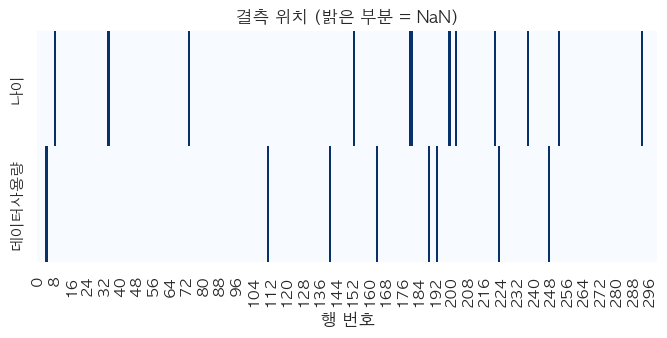

In [7]:
# 결측 위치를 그림으로: 흰 줄이 결측. 특정 구간에 몰려 있는지(패턴) 확인
fig, ax = plt.subplots(figsize=(8, 3))
sns.heatmap(df[["나이", "데이터사용량"]].isnull().T, cbar=False, cmap="Blues", ax=ax)
ax.set_title("결측 위치 (밝은 부분 = NaN)")
ax.set_xlabel("행 번호")
plt.show()

### 2.2 삭제: `dropna()`

| 옵션 | 의미 |
|------|------|
| `how="any"` (기본) | NaN 이 **하나라도** 있는 행 삭제 |
| `how="all"` | **모든 값** 이 NaN 인 행만 삭제 |
| `subset=["col"]` | 특정 컬럼의 NaN 만 기준으로 |
| `thresh=k` | NaN 아닌 값이 k 개 **이상** 인 행만 남김 |
| `axis=1` | 행이 아니라 **열** 을 삭제 (결측이 너무 많은 컬럼 제거) |

> 삭제 기준: 결측 비율이 **5% 미만** 이고 행이 충분하면 삭제해도 무방. 그 이상이면 대체를 고려. 컬럼의 **절반 이상** 이 결측이면 컬럼 자체를 삭제.

In [8]:
print("원본           :", df.shape)
print("how='any'      :", df.dropna().shape)
print("subset=['나이'] :", df.dropna(subset=["나이"]).shape)
print("thresh=11      :", df.dropna(thresh=11).shape, " <- 11개 컬럼 모두 값이 있어야 남김")
print("axis=1         :", df.dropna(axis=1).shape, " <- 결측이 있는 컬럼 2개가 사라짐")

원본           : (300, 11)
how='any'      : (280, 11)
subset=['나이'] : (288, 11)
thresh=11      : (280, 11)  <- 11개 컬럼 모두 값이 있어야 남김
axis=1         : (300, 9)  <- 결측이 있는 컬럼 2개가 사라짐


### 2.3 대체: `fillna()`

| 방법 | 코드 | 언제 |
|------|------|------|
| 상수 | `fillna(0)`, `fillna("없음")` | 결측 자체가 의미 있을 때 (예: 구매 없음 = 0) |
| 평균 | `fillna(df["col"].mean())` | 분포가 대칭이고 이상치가 없을 때 |
| **중앙값** | `fillna(df["col"].median())` | 치우친 분포·이상치가 있을 때 (**가장 무난**) |
| 최빈값 | `fillna(df["col"].mode()[0])` | **범주형** 컬럼 |
| 그룹별 | `fillna(df.groupby("g")["col"].transform("median"))` | 그룹마다 수준이 다를 때 |
| 앞/뒤 값 | `ffill()`, `bfill()` | **시계열** (직전 값이 가장 비슷) |
| 보간 | `interpolate()` | 시계열, 양 옆 값의 중간 |

> `mode()` 는 최빈값이 여러 개일 수 있어 **Series 를 반환** 합니다. 그래서 `[0]` 으로 첫 번째를 꺼냅니다.

In [9]:
# 평균 vs 중앙값: 치우친 데이터사용량은 둘의 차이가 크다
col = df["데이터사용량"]
print(f"평균 {col.mean():.1f} | 중앙값 {col.median():.1f} | 왜도 {col.skew():.2f}")
print("-> 헤비 유저가 평균을 끌어올리므로, 결측을 평균으로 채우면 '보통 사람'보다 큰 값이 들어간다. 중앙값이 안전.")

평균 15.1 | 중앙값 12.4 | 왜도 2.50
-> 헤비 유저가 평균을 끌어올리므로, 결측을 평균으로 채우면 '보통 사람'보다 큰 값이 들어간다. 중앙값이 안전.


In [10]:
# 방법별로 채운 결과 비교 (원본은 그대로 두고 복사본에 적용)
filled = pd.DataFrame({
  "원본": df["나이"],
  "평균": df["나이"].fillna(df["나이"].mean()),
  "중앙값": df["나이"].fillna(df["나이"].median()),
  "상수0": df["나이"].fillna(0),
})
filled[df["나이"].isna()].head()

,원본,평균,중앙값,상수0
8,NaN,43.892361,43.0,0.0
34,NaN,43.892361,43.0,0.0
73,NaN,43.892361,43.0,0.0
153,NaN,43.892361,43.0,0.0
180,NaN,43.892361,43.0,0.0


In [11]:
# 그룹별 대체: 요금제마다 사용량 수준이 다르므로 요금제별 중앙값으로
group_median = df.groupby("요금제")["데이터사용량"].transform("median")   # 행마다 자기 그룹의 중앙값
print(df.groupby("요금제")["데이터사용량"].median().round(1).to_dict())

df_filled = df.copy()
df_filled["나이"] = df_filled["나이"].fillna(df_filled["나이"].median())
df_filled["데이터사용량"] = df_filled["데이터사용량"].fillna(group_median)
print("\n대체 후 결측:", df_filled.isnull().sum().sum())

{'3G': 13.6, '5G': 12.1, 'LTE': 12.2}

대체 후 결측: 0


In [12]:
# 최빈값으로 범주형 채우기 (연습용으로 지역 3개를 비워 본다)
tmp = df.copy()
tmp.loc[[0, 1, 2], "지역"] = np.nan
mode_value = tmp["지역"].mode()[0]
print("최빈값:", mode_value, "| mode() 의 타입:", type(tmp["지역"].mode()).__name__)
tmp["지역"] = tmp["지역"].fillna(mode_value)
print("채운 뒤 0~2행:", tmp.loc[[0, 1, 2], "지역"].tolist())

최빈값: 경기 | mode() 의 타입: Series
채운 뒤 0~2행: ['경기', '경기', '경기']


In [13]:
# 시계열 결측: ffill / bfill / interpolate
ts = pd.Series([10.0, np.nan, np.nan, 16.0, np.nan, 20.0], index=pd.date_range("2024-01-01", periods=6))
pd.DataFrame({"원본": ts, "ffill": ts.ffill(), "bfill": ts.bfill(), "interpolate": ts.interpolate()})

,원본,ffill,bfill,interpolate
2024-01-01,10.0,10.0,10.0,10.0
2024-01-02,NaN,10.0,16.0,12.0
2024-01-03,NaN,10.0,16.0,14.0
2024-01-04,16.0,16.0,16.0,16.0
2024-01-05,NaN,16.0,20.0,18.0
2024-01-06,20.0,20.0,20.0,20.0


In [14]:
# 여러 컬럼을 한 번에: 사전으로 컬럼별 값 지정
df_multi = df.fillna({"나이": df["나이"].median(), "데이터사용량": df["데이터사용량"].median()})
print(df_multi.isnull().sum().sum())

0


### 2.4 scikit-learn 방식: `SimpleImputer`

pandas 로 충분하지만, **학습 데이터의 통계로 테스트 데이터를 채워야** 하는 상황(7절 스케일링과 같은 원리)에서는 `fit` / `transform` 구조가 편합니다.

In [15]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")        # mean, median, most_frequent, constant
num_part = df[["나이", "데이터사용량"]]
imputed = imputer.fit_transform(num_part)         # 결과는 numpy 배열
print("학습된 대체값:", imputer.statistics_)
pd.DataFrame(imputed, columns=num_part.columns).isnull().sum()

학습된 대체값: [43.   12.45]


나이        0
데이터사용량    0
dtype: int64

> **결측 처리 후 반드시 확인**: `df.isnull().sum().sum()` 이 0 인지. 시험 채점은 보통 이 값으로 합니다.

In [16]:
df = df_filled.copy()
print("현재 결측:", df.isnull().sum().sum())

현재 결측: 0


### 📝 시험 출제 포인트 (2장)

- "결측치가 있는 행을 모두 삭제하시오" → `df = df.dropna()`
- "`나이` 결측을 중앙값으로 대체하시오" → `df["나이"] = df["나이"].fillna(df["나이"].median())`
- "`지역` 결측을 최빈값으로" → `df["지역"].fillna(df["지역"].mode()[0])`
- "결측치가 없는지 확인" → `df.isnull().sum()`
- 결측이 많은 컬럼 삭제 → `df.drop(columns=["col"])`

### ⚠️ 자주 하는 실수 (2장)

- **`fillna` 결과를 대입하지 않음**: `df["나이"].fillna(0)` 만 쓰면 원본은 그대로. `df["나이"] = ...` 또는 `inplace=True`.
- **`mode()` 에 `[0]` 누락**: Series 가 통째로 들어가 엉뚱하게 채워집니다.
- **문자열 `"NaN"` 과 진짜 `NaN`**: 파일에 `"?"`, `"-"`, `"없음"` 으로 적힌 결측은 `isnull()` 에 안 잡힙니다. 1회차 `na_values` 또는 `replace("?", np.nan)`.
- **테스트 데이터를 자기 통계로 채움**: 학습 데이터의 중앙값으로 채워야 정보 누출(leakage)이 없습니다. (7절)

---
## 3. 이상치 처리

### 한 줄 정의
**이상치 (Outlier)**: 다른 값들과 동떨어진 극단값. 입력 오류일 수도, 진짜 특이 고객일 수도 있다.

### 직관적 설명
반 평균 키를 구하는데 농구 선수 한 명이 섞이면 평균이 왜곡됩니다. 선형 회귀·평균 기반 모델은 이런 값에 크게 흔들리므로 **찾아서 판단** 해야 합니다. 단, 이상치가 항상 "틀린 값"은 아닙니다. 헤비 유저는 실제로 존재합니다.

### 3.1 IQR 규칙으로 찾기 (3회차 박스플롯의 수식)

```
Q1 = 25% 지점,  Q3 = 75% 지점,  IQR = Q3 - Q1
하한 = Q1 - 1.5 × IQR,  상한 = Q3 + 1.5 × IQR   → 이 범위 밖이면 이상치
```

In [17]:
def iqr_bounds(s: pd.Series, k: float = 1.5) -> tuple[float, float]:
  q1, q3 = s.quantile([0.25, 0.75])
  iqr = q3 - q1
  return q1 - k * iqr, q3 + k * iqr


for col in ["나이", "월요금", "데이터사용량", "가입개월수"]:
  low, high = iqr_bounds(df[col])
  n_out = ((df[col] < low) | (df[col] > high)).sum()
  print(f"{col:<8} 하한 {low:>9.1f} | 상한 {high:>9.1f} | 이상치 {n_out:>3}개")

나이       하한      -4.0 | 상한      92.0 | 이상치   0개
월요금      하한  -31000.0 | 상한  145000.0 | 이상치   0개
데이터사용량   하한       0.8 | 상한      24.0 | 이상치  28개
가입개월수    하한     -27.5 | 상한     104.5 | 이상치   0개


In [18]:
low, high = iqr_bounds(df["데이터사용량"])
outliers = df[df["데이터사용량"] > high]
print(f"상한 {high:.1f} 초과 고객 {len(outliers)}명. 요금제 분포:", outliers["요금제"].value_counts().to_dict())
outliers[["고객ID", "요금제", "데이터사용량"]].head()

상한 24.0 초과 고객 28명. 요금제 분포: {'LTE': 12, '5G': 12, '3G': 4}


,고객ID,요금제,데이터사용량
17,C0018,LTE,57.4
27,C0028,LTE,51.3
51,C0052,LTE,36.9
68,C0069,LTE,43.3
74,C0075,5G,36.3


### 3.2 처리 방법 세 가지

| 방법 | 코드 | 장점 | 단점 |
|------|------|------|------|
| **제거** | `df[(df[c] >= low) & (df[c] <= high)]` | 간단 | 데이터 손실, 진짜 특이 고객 정보도 사라짐 |
| **clip (경계값으로 대체)** | `df[c].clip(lower=low, upper=high)` | 행 수 유지 | 극단값들이 모두 같은 값이 됨 |
| **로그 변환** | `np.log1p(df[c])` | 분포 자체를 완만하게, 정보 보존 | 해석 시 역변환(`np.expm1`) 필요, 음수 불가 |

> 시험에서는 보통 **제거** 또는 **clip** 을 지정합니다. 실무에서는 모델 종류에 따라 다릅니다 (트리 모델은 이상치에 강해서 그대로 두기도 함).

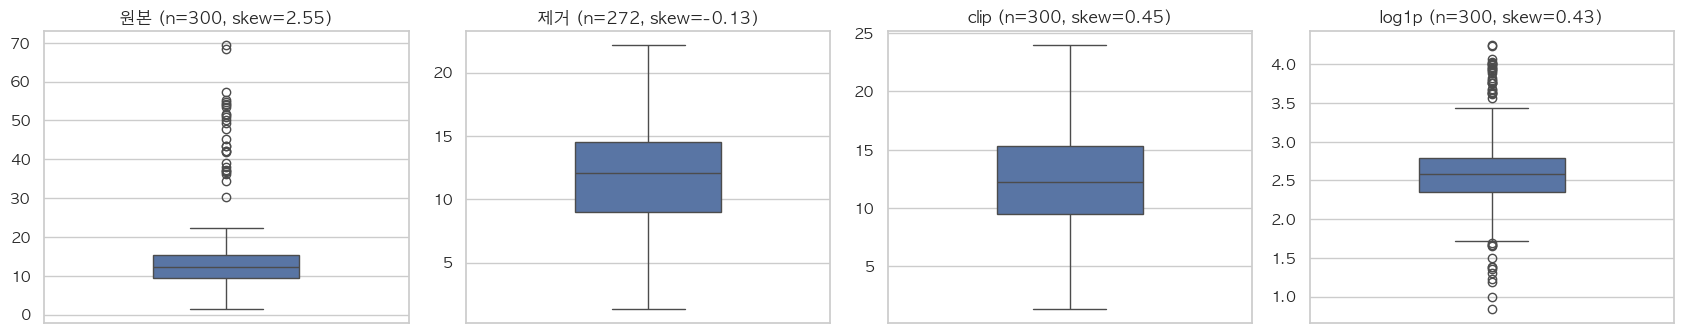

In [19]:
s = df["데이터사용량"]
removed = s[(s >= low) & (s <= high)]
clipped = s.clip(lower=low, upper=high)
logged = np.log1p(s)

fig, axes = plt.subplots(1, 4, figsize=(17, 3.5))
for ax, (name, data) in zip(axes, [("원본", s), ("제거", removed), ("clip", clipped), ("log1p", logged)]):
  sns.boxplot(y=data, ax=ax, width=0.4)
  ax.set_title(f"{name} (n={len(data)}, skew={data.skew():.2f})")
  ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [20]:
# 이 과정에서는 행 수를 유지하는 clip 을 채택한다
df["데이터사용량"] = df["데이터사용량"].clip(upper=high)
print("clip 후 최대값:", df["데이터사용량"].max(), "| 행 수:", len(df))

clip 후 최대값: 24.0 | 행 수: 300


### 3.3 (참고) z-score 규칙

정규분포에 가까운 컬럼이면 **평균에서 표준편차의 3배 이상** 떨어진 값을 이상치로 봅니다. 치우친 분포에는 IQR 이 더 안전합니다.

In [21]:
z = (df["나이"] - df["나이"].mean()) / df["나이"].std()
print("|z| > 3 인 나이:", (z.abs() > 3).sum(), "개  (나이는 대칭 분포라 이상치 없음)")

|z| > 3 인 나이: 0 개  (나이는 대칭 분포라 이상치 없음)


---
## 4. 구간화 (Binning)

### 한 줄 정의
연속된 숫자를 **몇 개의 구간(범주)** 으로 묶는 것. 나이 → 연령대, 점수 → 등급.

### 직관적 설명
"37세" 보다 "30대" 가 설명하기 쉽고, 트리 모델은 어차피 구간으로 나눠서 판단합니다. 이상치의 영향도 줄어듭니다. 대신 구간 안의 세밀한 차이는 사라집니다.

| 함수 | 기준 | 결과 | 언제 |
|------|------|------|------|
| `pd.cut(x, bins=[...], labels=[...])` | **값의 경계** 를 직접 지정 | 구간마다 개수가 다름 | 의미 있는 경계가 있을 때 (연령대, 등급 기준) |
| `pd.cut(x, bins=5)` | 최소~최대를 **같은 폭** 으로 5등분 | 구간마다 개수가 다름 | 빠른 확인 |
| `pd.qcut(x, q=4, labels=[...])` | **개수** 가 같도록 4등분 (사분위) | 구간마다 개수가 비슷 | 상·중·하 등급처럼 균등 분할 |

`right=True` (기본) 는 구간의 **오른쪽 끝을 포함**: `(0, 29]` 는 29 포함, 30 미포함.

In [22]:
bins = [0, 29, 39, 49, 59, 100]
labels = ["20대", "30대", "40대", "50대", "60대+"]
df["연령대"] = pd.cut(df["나이"], bins=bins, labels=labels)
print(df["연령대"].value_counts().sort_index(), "\n")
print("dtype:", df["연령대"].dtype)      # category 타입
df[["나이", "연령대"]].head()

연령대
20대     58
30대     64
40대     65
50대     58
60대+    55
Name: count, dtype: int64 

dtype: category


,나이,연령대
0,46.0,40대
1,54.0,50대
2,58.0,50대
3,67.0,60대+
4,48.0,40대


In [23]:
# right=False: 왼쪽 끝 포함 [30, 40) -> 30 은 30대, 40 은 40대
alt = pd.cut(df["나이"], bins=[0, 30, 40, 50, 60, 100], labels=labels, right=False)
compare = pd.DataFrame({"나이": df["나이"], "right=True": df["연령대"], "right=False": alt})
compare[compare["나이"].isin([30, 40, 50])].drop_duplicates("나이")

,나이,right=True,right=False
5,50.0,50대,50대
56,30.0,30대,30대
105,40.0,40대,40대


In [24]:
# qcut: 데이터사용량을 개수가 같은 3등급으로
df["사용량등급"] = pd.qcut(df["데이터사용량"], q=3, labels=["저", "중", "고"])
print(df["사용량등급"].value_counts())
print("\n등급별 경계:", pd.qcut(df["데이터사용량"], q=3).cat.categories.tolist())

사용량등급
저    104
고     99
중     97
Name: count, dtype: int64

등급별 경계: [Interval(1.2990000000000002, 10.7, closed='right'), Interval(10.7, 14.2, closed='right'), Interval(14.2, 24.0, closed='right')]


In [25]:
# 구간화된 컬럼으로 타깃 비율 확인 (3회차 복습): 구간화의 목적은 이런 해석
df.groupby("연령대", observed=True)["이탈여부"].apply(lambda s: (s == "Yes").mean()).round(3)

연령대
20대     0.190
30대     0.172
40대     0.231
50대     0.224
60대+    0.164
Name: 이탈여부, dtype: float64

### 📝 시험 출제 포인트 (3·4장)

- "IQR 방식으로 `월요금` 이상치를 제거하시오" → Q1, Q3, IQR 계산 후 `df[(df[c] >= Q1 - 1.5*IQR) & (df[c] <= Q3 + 1.5*IQR)]`
- "`나이` 를 10 단위 구간으로 나눠 `연령대` 컬럼 생성" → `pd.cut(df["나이"], bins=[...], labels=[...])`
- "`점수` 를 4분위로 나눠 등급 부여" → `pd.qcut(df["점수"], q=4, labels=[...])`

### ⚠️ 자주 하는 실수 (3·4장)

- **bins 와 labels 개수 불일치**: 경계가 n+1 개면 라벨은 n 개. `ValueError: Bin labels must be one fewer than the number of bin edges`.
- **경계값 포함 여부 혼동**: `right=True` 가 기본이라 `bins=[0, 30, 40]` 에서 30 은 첫 구간에 들어갑니다. 문제가 "30 이상 40 미만" 이면 `right=False`.
- **이상치 제거 후 인덱스 비연속**: `reset_index(drop=True)` 를 해 두면 뒤에서 `concat` 할 때 문제가 없습니다.
- **이상치를 무조건 지움**: 타깃과 관련된 특이 고객(헤비 유저의 이탈 등)을 잃을 수 있습니다. 먼저 EDA 로 성격을 확인합니다.

---
## 5. 인코딩 (범주형 → 숫자)

### 한 줄 정의
문자열 범주를 **모델이 계산할 수 있는 숫자** 로 바꾸는 것.

### 직관적 설명
컴퓨터는 "서울" 과 "부산" 의 거리를 모릅니다. 숫자로 바꿔 줘야 하는데, **바꾸는 방식이 의미를 만들어 냅니다.** 서울=1, 경기=2, 부산=3 으로 하면 모델은 "부산이 서울의 3배" 라고 오해할 수 있습니다.

| 범주 종류 | 예시 | 방법 | 결과 |
|------|------|------|------|
| **이진** (값 2개) | 성별 M/F, 이탈여부 Yes/No | `map({"M": 0, "F": 1})` | 컬럼 1개, 0/1 |
| **순서형** (크기 순서 있음) | 3G < LTE < 5G, 하<중<상 | `map({"3G": 0, "LTE": 1, "5G": 2})` | 컬럼 1개, 순서 있는 정수 |
| **명목형** (순서 없음) | 지역, 색상 | `pd.get_dummies()` (원-핫) | 범주 수만큼 0/1 컬럼 |
| 타깃(y) 라벨 | 품종 이름 | `LabelEncoder` | 0, 1, 2… (순서 의미 없어도 y 는 괜찮음) |

In [26]:
# 현재 문자열 컬럼 확인
obj_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
print("인코딩 대상:", obj_cols)
for c in obj_cols:
  print(f"  {c:<6}: {df[c].nunique()}종 -> {df[c].unique()[:5].tolist()}")

인코딩 대상: ['고객ID', '성별', '지역', '우편번호', '요금제', '이탈여부', '연령대', '사용량등급']
  고객ID  : 300종 -> ['C0001', 'C0002', 'C0003', 'C0004', 'C0005']
  성별    : 2종 -> ['M', 'F']
  지역    : 5종 -> ['경기', '부산', '대구', '서울', '기타']
  우편번호  : 300종 -> ['38671', '47947', '23029', '09262', '25370']
  요금제   : 3종 -> ['5G', 'LTE', '3G']
  이탈여부  : 2종 -> ['No', 'Yes']
  연령대   : 5종 -> ['40대', '50대', '60대+', '30대', '20대']
  사용량등급 : 3종 -> ['고', '중', '저']


### 5.1 이진·순서형: `map()`

사전(dict)으로 직접 지정하므로 **어느 값이 0 이고 1 인지 내가 정합니다.** 이탈여부는 관심 있는 쪽(Yes)을 1 로 두는 것이 관례입니다.

In [27]:
df["성별"] = df["성별"].map({"M": 0, "F": 1})
df["이탈여부"] = df["이탈여부"].map({"No": 0, "Yes": 1})
df["요금제"] = df["요금제"].map({"3G": 0, "LTE": 1, "5G": 2})     # 세대 순서를 살린 순서형 인코딩
df[["성별", "이탈여부", "요금제"]].head()

,성별,이탈여부,요금제
0,0,0,2
1,0,0,2
2,0,0,1
3,1,0,1
4,0,1,2


In [28]:
# map 은 사전에 없는 값을 NaN 으로 만든다 -> 오타·누락 확인 습관
print("map 후 결측:", df[["성별", "이탈여부", "요금제"]].isnull().sum().to_dict())

map 후 결측: {'성별': 0, '이탈여부': 0, '요금제': 0}


### 5.2 명목형: 원-핫 인코딩 `pd.get_dummies()`

지역 5종 → 지역_경기, 지역_대구, 지역_부산, 지역_서울, 지역_기타 처럼 **컬럼을 펼치고 해당하는 곳만 1**.

| 옵션 | 의미 |
|------|------|
| `columns=["지역"]` | 지정한 컬럼만 변환 (생략하면 모든 object 컬럼) |
| `drop_first=True` | 첫 범주 컬럼을 삭제. 나머지가 전부 0 이면 첫 범주이므로 정보 손실 없음. **선형 모델에서 다중공선성 방지** |
| `dtype=int` | 결과를 True/False 대신 0/1 로 (pandas 2.x 기본은 bool) |

In [29]:
dummies = pd.get_dummies(df["지역"], prefix="지역", dtype=int)
print("펼쳐진 컬럼:", dummies.columns.tolist())
pd.concat([df["지역"], dummies], axis=1).head()

펼쳐진 컬럼: ['지역_경기', '지역_기타', '지역_대구', '지역_부산', '지역_서울']


,지역,지역_경기,지역_기타,지역_대구,지역_부산,지역_서울
0,경기,1,0,0,0,0
1,부산,0,0,0,1,0
2,대구,0,0,1,0,0
3,경기,1,0,0,0,0
4,경기,1,0,0,0,0


In [30]:
# DataFrame 전체에 적용: columns 로 대상 지정, drop_first 로 한 컬럼 절약
df = pd.get_dummies(df, columns=["지역"], drop_first=True, dtype=int)
print(df.shape)
print([c for c in df.columns if c.startswith("지역")])
df.head(3)

(300, 16)
['지역_기타', '지역_대구', '지역_부산', '지역_서울']


,고객ID,성별,나이,우편번호,요금제,월요금,데이터사용량,가입일,가입개월수,이탈여부,연령대,사용량등급,지역_기타,지역_대구,지역_부산,지역_서울
0,C0001,0,46.0,38671,2,29000.0,17.0,2021-11-19,37,0,40대,고,0,0,0,0
1,C0002,0,54.0,47947,2,65000.0,11.0,2019-11-22,62,0,50대,중,0,0,1,0
2,C0003,0,58.0,23029,1,89000.0,13.5,2019-08-12,65,0,50대,중,0,1,0,0


> **drop_first 판단**: 시험 문제가 지정하면 그대로. 지정이 없으면 **선형·로지스틱 회귀는 `True`**, 트리 계열은 어느 쪽이든 무방합니다.

### 5.3 `LabelEncoder` 와 `OneHotEncoder` (scikit-learn)

- `LabelEncoder` : 문자열을 **알파벳/가나다 순** 으로 0, 1, 2… 부여. 순서를 내가 정할 수 없어서 **X 의 명목형에는 부적합**, 주로 **y** 에 씁니다.
- `OneHotEncoder` : `get_dummies` 의 sklearn 버전. `fit` / `transform` 구조라 학습 데이터에 없던 범주가 테스트에 나타나도 처리 규칙(`handle_unknown`)을 둘 수 있습니다.

In [31]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le = LabelEncoder()
encoded = le.fit_transform(["LTE", "5G", "3G", "LTE"])
print("LabelEncoder 결과:", encoded, "| 클래스 순서:", le.classes_, " <- 문자열 정렬 순서라 3G < 5G < LTE 가 되어 버림")
print("역변환:", le.inverse_transform([0, 1, 2]))

LabelEncoder 결과: [2 1 0 2] | 클래스 순서: ['3G' '5G' 'LTE']  <- 문자열 정렬 순서라 3G < 5G < LTE 가 되어 버림
역변환: ['3G' '5G' 'LTE']


In [32]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
sample = pd.DataFrame({"지역": ["서울", "부산", "서울", "대구"]})
ohe.fit(sample)
print("학습된 범주:", ohe.categories_)
print("새 데이터(학습에 없던 '제주' 포함) 변환:\n", ohe.transform(pd.DataFrame({"지역": ["부산", "제주"]})))

학습된 범주: [array(['대구', '부산', '서울'], dtype=object)]
새 데이터(학습에 없던 '제주' 포함) 변환:
 [[0. 1. 0.]
 [0. 0. 0.]]


In [33]:
# 이제 문자열이 없다. 연령대·사용량등급은 실습용이었으므로 제거하고, 모델에 안 쓰는 식별자·날짜도 제거
df = df.drop(columns=["연령대", "사용량등급", "고객ID", "우편번호", "가입일"])
print(df.dtypes)

성별          int64
나이        float64
요금제         int64
월요금       float64
데이터사용량    float64
가입개월수       int64
이탈여부        int64
지역_기타       int64
지역_대구       int64
지역_부산       int64
지역_서울       int64
dtype: object


### 📝 시험 출제 포인트 (5장)

- "`성별` 을 남=0, 여=1 로 변환" → `map({"M": 0, "F": 1})`
- "범주형 변수를 원-핫 인코딩하시오 (`drop_first=True`)" → `pd.get_dummies(df, columns=[...], drop_first=True)`
- "object 타입 컬럼을 모두 원-핫 인코딩" → `pd.get_dummies(df)` (columns 생략) — 이때 **타깃이 문자열이면 먼저 분리** 해야 함
- "`LabelEncoder` 로 `등급` 을 변환" → `le.fit_transform(df["등급"])`

### ⚠️ 자주 하는 실수 (5장)

- **타깃까지 원-핫**: `pd.get_dummies(df)` 에 이탈여부(Yes/No)가 포함되면 `이탈여부_Yes` 로 바뀝니다. 타깃은 `map` 으로 따로 처리하거나 먼저 분리.
- **`get_dummies` 결과의 bool**: pandas 2.x 는 True/False 로 나옵니다. 대부분 모델은 그대로 받지만 `dtype=int` 가 안전합니다.
- **명목형에 `LabelEncoder`**: 서울=3, 부산=2 처럼 없는 순서가 생깁니다. X 의 명목형은 원-핫.
- **테스트 데이터에 새 범주**: `get_dummies` 를 train/test 따로 하면 컬럼 수가 달라집니다. **분할 전에 인코딩** 하거나 `OneHotEncoder(handle_unknown="ignore")`.

---
## 6. 데이터 분할: `train_test_split`

### 한 줄 정의
데이터를 **학습용(train)** 과 **평가용(test)** 으로 나눠, 모델이 **처음 보는 데이터** 에서 얼마나 맞히는지 재는 준비.

### 직관적 설명
기출문제로만 공부하고 기출문제로 시험을 보면 100점이 나옵니다. 그건 실력이 아니라 **암기(과적합)** 입니다. 문제집의 일부를 봉인해 두었다가 마지막에 푸는 것이 test 데이터입니다.

| 파라미터 | 의미 | 관례 |
|------|------|------|
| `test_size` | 평가용 비율 | 0.2 ~ 0.3 |
| `random_state` | 섞는 방식 고정 → **재현 가능** | 42 등 아무 정수. 시험은 문제가 지정 |
| `stratify=y` | **y 의 클래스 비율** 을 train/test 에 똑같이 유지 | 분류 문제, 특히 불균형일 때 필수 |
| `shuffle` | 섞을지 여부 (기본 True) | 시계열은 False |

반환 순서는 **항상 `X_train, X_test, y_train, y_test`** 입니다. 순서를 바꾸면 조용히 잘못된 결과가 나옵니다.

In [34]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["이탈여부"])
y = df["이탈여부"]
print("X:", X.shape, "| y:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("train:", X_train.shape, y_train.shape, "| test:", X_test.shape, y_test.shape)

X: (300, 10) | y: (300,)
train: (240, 10) (240,) | test: (60, 10) (60,)


In [35]:
# stratify 의 효과: 클래스 비율이 유지되는지 비교
def ratio(s: pd.Series) -> float:
  return round(s.mean(), 3)     # 0/1 이므로 평균 = 1 의 비율


_, _, y_tr_no, y_te_no = train_test_split(X, y, test_size=0.2, random_state=7)               # stratify 없음
_, _, y_tr_st, y_te_st = train_test_split(X, y, test_size=0.2, random_state=7, stratify=y)   # stratify 있음

pd.DataFrame({
  "전체": [ratio(y), ratio(y)],
  "stratify 없음": [ratio(y_tr_no), ratio(y_te_no)],
  "stratify=y": [ratio(y_tr_st), ratio(y_te_st)],
}, index=["train 이탈률", "test 이탈률"])

,전체,stratify 없음,stratify=y
train 이탈률,0.197,0.188,0.196
test 이탈률,0.197,0.233,0.200


In [36]:
# random_state 가 같으면 몇 번을 나눠도 같은 결과 (재현성)
a = train_test_split(X, y, test_size=0.2, random_state=42)[0].index[:5].tolist()
b = train_test_split(X, y, test_size=0.2, random_state=42)[0].index[:5].tolist()
c = train_test_split(X, y, test_size=0.2, random_state=0)[0].index[:5].tolist()
print("42:", a, "\n42:", b, "\n 0:", c)

42: [232, 59, 6, 185, 173] 
42: [232, 59, 6, 185, 173] 
 0: [134, 145, 63, 293, 285]


---
## 7. 스케일링 (Feature Scaling)

### 한 줄 정의
컬럼마다 다른 **단위·크기를 비슷한 범위로** 맞추는 것.

### 직관적 설명
월요금(수만 원 단위)과 나이(수십 단위)를 같은 식에 넣으면, 거리·기울기 기반 모델은 **월요금의 숫자가 크다는 이유만으로** 월요금을 중요하게 봅니다. 모든 컬럼을 같은 출발선에 세우는 작업입니다.

| 스케일러 | 공식 | 결과 범위 | 특징 | 언제 |
|------|------|:---:|------|------|
| **MinMaxScaler** | (x − min) / (max − min) | **0 ~ 1** | 이상치에 민감 (max 가 튀면 나머지가 0 근처로 몰림) | 딥러닝 입력, 범위가 명확할 때 |
| **StandardScaler** | (x − 평균) / 표준편차 | 평균 0, 표준편차 1 | 이상치 영향 적음, 범위 제한 없음 | 선형·로지스틱 회귀, SVM, PCA (**기본 선택**) |
| RobustScaler | (x − 중앙값) / IQR | 제한 없음 | 이상치에 가장 강함 | 이상치가 많을 때 |

**스케일링이 필요한 모델**: 선형/로지스틱 회귀, KNN, SVM, 신경망, K-Means, PCA  
**필요 없는 모델**: 의사결정나무, 랜덤포레스트, 그라디언트부스팅 (값의 순서만 보므로)

### 🔑 가장 중요한 규칙: `fit` 은 train 에만

```
scaler.fit(X_train)             # train 의 최소·최대(또는 평균·표준편차)를 기억
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)    # test 는 train 의 기준으로 변환만!
```

test 데이터의 통계를 쓰면 **모델이 시험 문제를 미리 엿본 셈(정보 누출, data leakage)** 이 되어 성능이 과대평가됩니다. 그래서 분할이 스케일링보다 먼저입니다.

In [37]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

num_cols = ["나이", "요금제", "월요금", "데이터사용량", "가입개월수"]   # 0/1 원-핫·이진 컬럼은 스케일링 불필요
print(X_train[num_cols].describe().loc[["min", "max", "mean", "std"]].round(1))

        나이  요금제      월요금  데이터사용량  가입개월수
min   19.0  0.0  29000.0     2.3    6.0
max   69.0  2.0  89000.0    24.0   72.0
mean  44.0  1.3  55516.7    13.0   41.0
std   14.3  0.7  20446.1     5.3   18.9


In [38]:
# MinMaxScaler: train 으로 fit, train/test 모두 transform
mm = MinMaxScaler()
X_train_mm = X_train.copy()
X_test_mm = X_test.copy()
X_train_mm[num_cols] = mm.fit_transform(X_train[num_cols])     # fit + transform 을 한 번에
X_test_mm[num_cols] = mm.transform(X_test[num_cols])           # transform 만!

print("train 범위:", X_train_mm[num_cols].min().round(2).tolist(), "~", X_train_mm[num_cols].max().round(2).tolist())
print("test  범위:", X_test_mm[num_cols].min().round(2).tolist(), "~", X_test_mm[num_cols].max().round(2).tolist())
print("-> test 는 train 의 min/max 기준이라 0~1 을 살짝 벗어날 수 있다. 정상이다.")

train 범위: [0.0, 0.0, 0.0, 0.0, 0.0] ~ [1.0, 1.0, 1.0, 1.0, 1.0]
test  범위: [0.0, 0.0, 0.0, -0.05, 0.0] ~ [1.0, 1.0, 1.0, 1.0, 0.97]
-> test 는 train 의 min/max 기준이라 0~1 을 살짝 벗어날 수 있다. 정상이다.


In [39]:
# StandardScaler
ss = StandardScaler()
X_train_ss = X_train.copy()
X_test_ss = X_test.copy()
X_train_ss[num_cols] = ss.fit_transform(X_train[num_cols])
X_test_ss[num_cols] = ss.transform(X_test[num_cols])

print("학습된 평균:", ss.mean_.round(1))
print("train 평균 :", X_train_ss[num_cols].mean().round(2).tolist(), "(≈0)")
print("train 표준편차:", X_train_ss[num_cols].std().round(2).tolist(), "(≈1)")

학습된 평균: [4.40000e+01 1.30000e+00 5.55167e+04 1.30000e+01 4.10000e+01]
train 평균 : [-0.0, 0.0, 0.0, -0.0, -0.0] (≈0)
train 표준편차: [1.0, 1.0, 1.0, 1.0, 1.0] (≈1)


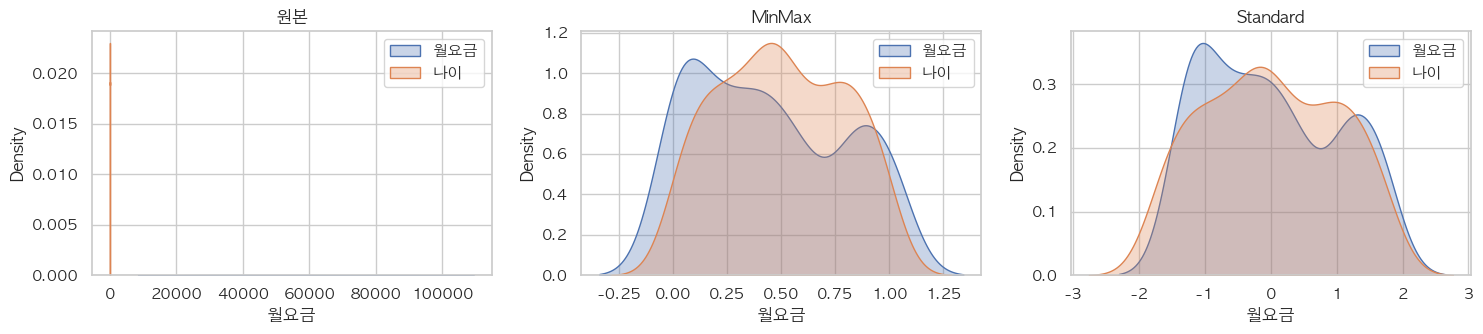

In [40]:
# 스케일링 전후 분포 비교: 모양은 그대로, 축의 눈금만 바뀐다
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, (name, data) in zip(axes, [("원본", X_train), ("MinMax", X_train_mm), ("Standard", X_train_ss)]):
  for c in ["월요금", "나이"]:
    sns.kdeplot(data[c], label=c, fill=True, alpha=0.3, ax=ax)
  ax.set_title(name)
  ax.legend()
plt.tight_layout()
plt.show()

In [41]:
# 스케일러 결과는 numpy 배열 -> DataFrame 으로 되돌리려면 컬럼명을 다시 붙인다 (시험에서 자주 필요)
arr = ss.transform(X_test[num_cols])
print(type(arr).__name__, arr.shape)
back = pd.DataFrame(arr, columns=num_cols, index=X_test.index)
back.head(3)

ndarray (60, 5)


,나이,요금제,월요금,데이터사용량,가입개월수
1,0.703886,0.978818,0.464791,-0.378159,1.111577
68,-0.701543,-0.489409,-0.515436,2.074510,-0.849640
215,1.125514,-1.957635,-0.025323,0.187841,1.270594


In [42]:
# 잘못된 예: test 로 따로 fit -> 같은 값이 train 과 test 에서 다르게 변환된다 (정보 누출)
wrong = StandardScaler().fit(X_test[num_cols])
sample_row = X_test[num_cols].iloc[[0]]
print("올바른 변환(train 기준):", ss.transform(sample_row).round(2))
print("잘못된 변환(test 기준) :", wrong.transform(sample_row).round(2))

올바른 변환(train 기준): [[ 0.7   0.98  0.46 -0.38  1.11]]
잘못된 변환(test 기준) : [[ 0.73  0.87  0.55 -0.3   1.26]]


### 📝 시험 출제 포인트 (6·7장)

- "`X`, `y` 로 분리하고 8:2 로 분할, `random_state=42`, `stratify` 적용" → `train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)`
- "`MinMaxScaler` 로 스케일링하여 `X_train_scaled`, `X_test_scaled` 생성" → `fit_transform(X_train)`, `transform(X_test)`
- "`StandardScaler` 를 적용" → 같은 구조
- 반환 변수명(`X_train, X_test, y_train, y_test`)은 **문제가 지정한 이름 그대로**

### ⚠️ 자주 하는 실수 (6·7장)

- **분할 전에 스케일링**: 전체 데이터로 `fit` 하면 정보 누출. 순서는 분할 → 스케일링.
- **test 에 `fit_transform`**: `transform` 만 써야 합니다.
- **반환 순서 혼동**: `X_train, y_train, X_test, y_test` 로 받으면 모양이 안 맞아 뒤에서 에러. 항상 `X_train, X_test, y_train, y_test`.
- **`stratify=y` 를 회귀에 사용**: 연속값에는 클래스가 없어 `ValueError`. 분류에만.
- **스케일링 후 컬럼명 소실**: 결과가 numpy 라 `df.columns` 로 되돌려야 해석·시각화가 편합니다.

---
## 8. 전체 전처리를 함수 하나로

오늘 한 작업을 **함수로 정리** 해 두면 5회차 이후 매번 재사용할 수 있습니다. 시험에서도 "앞 문항의 결과를 이어서" 진행하므로, 처리 순서를 한눈에 보는 습관이 중요합니다.

In [43]:
def preprocess_customers(raw: pd.DataFrame) -> pd.DataFrame:
  """고객 데이터 전처리: 결측 대체 -> 이상치 clip -> 인코딩. 분할·스케일링은 모델링 단계에서."""
  out = raw.copy()

  # 1) 모델에 쓰지 않는 식별자·날짜 제거
  out = out.drop(columns=["고객ID", "우편번호", "가입일"])

  # 2) 결측치: 나이는 전체 중앙값, 데이터사용량은 요금제별 중앙값
  out["나이"] = out["나이"].fillna(out["나이"].median())
  out["데이터사용량"] = out["데이터사용량"].fillna(out.groupby("요금제")["데이터사용량"].transform("median"))

  # 3) 이상치: 데이터사용량을 IQR 상한으로 clip
  q1, q3 = out["데이터사용량"].quantile([0.25, 0.75])
  upper = q3 + 1.5 * (q3 - q1)
  out["데이터사용량"] = out["데이터사용량"].clip(upper=upper)

  # 4) 인코딩: 이진 -> 0/1, 순서형 -> 정수, 명목형 -> 원-핫
  out["성별"] = out["성별"].map({"M": 0, "F": 1})
  out["이탈여부"] = out["이탈여부"].map({"No": 0, "Yes": 1})
  out["요금제"] = out["요금제"].map({"3G": 0, "LTE": 1, "5G": 2})
  out = pd.get_dummies(out, columns=["지역"], drop_first=True, dtype=int)
  return out


raw = pd.read_csv(f"{DATA_DIR}/customers.csv", dtype={"우편번호": str}, parse_dates=["가입일"])
clean = preprocess_customers(raw)
print(clean.shape, "| 결측:", clean.isnull().sum().sum(), "| 문자열 컬럼:", clean.select_dtypes("object").shape[1])
clean.head(3)

(300, 11) | 결측: 0 | 문자열 컬럼: 0


,성별,나이,요금제,월요금,데이터사용량,가입개월수,이탈여부,지역_기타,지역_대구,지역_부산,지역_서울
0,0,46.0,2,29000.0,17.0,37,0,0,0,0,0
1,0,54.0,2,65000.0,11.0,62,0,0,0,1,0
2,0,58.0,1,89000.0,13.5,65,0,0,1,0,0


In [44]:
# 5회차에서 바로 쓸 수 있도록 저장 (분할·스케일링은 모델마다 다르므로 저장하지 않는다)
clean.to_csv(f"{DATA_DIR}/customers_clean.csv", index=False)
print("저장:", f"{DATA_DIR}/customers_clean.csv", "| 컬럼:", clean.columns.tolist())

저장: data/customers_clean.csv | 컬럼: ['성별', '나이', '요금제', '월요금', '데이터사용량', '가입개월수', '이탈여부', '지역_기타', '지역_대구', '지역_부산', '지역_서울']


#### 오늘 전처리 결정 요약 (3회차 가설 → 4회차 실행)

| 컬럼 | 문제 | 결정 | 이유 |
|------|------|------|------|
| 고객ID, 우편번호, 가입일 | 예측에 무의미 / 날짜형 | 삭제 | 가입일 정보는 가입개월수에 이미 반영 |
| 나이 | 결측 12개 | 중앙값 대체 | 대칭 분포라 평균도 무방하지만 중앙값이 안전 |
| 데이터사용량 | 결측 8개, 오른쪽 꼬리 | 요금제별 중앙값 대체 → IQR 상한 clip | 요금제마다 사용량 수준이 다름, 행 수 유지 |
| 성별, 이탈여부 | 문자열 이진 | `map` 0/1 | 관심 클래스(Yes)를 1 로 |
| 요금제 | 문자열, 세대 순서 있음 | 순서형 정수 0/1/2 | 순서 정보 보존 |
| 지역 | 문자열 명목형 5종 | 원-핫 (`drop_first=True`) | 순서가 없음, 선형 모델 대비 |

---
## 9. 종합 실습

원본 `data/customers.csv` 를 다시 읽어 AICE 형식으로 진행합니다. **변수명은 지정된 대로** 사용하세요.

In [45]:
df = pd.read_csv(f"{DATA_DIR}/customers.csv", dtype={"우편번호": str}, parse_dates=["가입일"])
print(df.shape)

(300, 11)


### 문제 1. 결측치 처리

`나이` 의 결측은 **평균(정수로 반올림)** 으로, `데이터사용량` 의 결측은 **중앙값** 으로 대체하시오. 처리 후 전체 결측치 개수를 출력하시오.

In [46]:
# 여기에 코드를 작성하세요

<details>
<summary>정답 보기</summary>

```python
df["나이"] = df["나이"].fillna(round(df["나이"].mean()))
df["데이터사용량"] = df["데이터사용량"].fillna(df["데이터사용량"].median())
print(df.isnull().sum().sum())
```

</details>

### 문제 2. 이상치 제거

`월요금` 에 IQR 규칙(1.5배)을 적용하여 이상치 행을 **제거** 하고, 남은 행 수를 출력하시오. 인덱스는 0부터 다시 매기시오.

In [47]:
# 여기에 코드를 작성하세요

<details>
<summary>정답 보기</summary>

```python
q1, q3 = df["월요금"].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
df = df[(df["월요금"] >= low) & (df["월요금"] <= high)].reset_index(drop=True)
print(len(df))    # 월요금은 7개 값이라 이상치가 없어 300 그대로
```

</details>

### 문제 3. 구간화

`가입개월수` 를 `[0, 12, 36, 200]` 경계로 나눠 `가입기간` 컬럼(`"1년미만"`, `"1~3년"`, `"3년이상"`)을 만들고, 값별 개수를 출력하시오. 12개월은 `"1년미만"` 에 **포함되지 않아야** 한다.

In [48]:
# 여기에 코드를 작성하세요

<details>
<summary>정답 보기</summary>

```python
df["가입기간"] = pd.cut(df["가입개월수"], bins=[0, 12, 36, 200], labels=["1년미만", "1~3년", "3년이상"], right=False)
print(df["가입기간"].value_counts())
```

`right=False` 로 `[0, 12)` 구간이 되어 12 는 "1~3년" 에 들어간다. (`right=True` 였다면 `(0, 12]` 라 12 가 1년미만에 포함)

</details>

### 문제 4. 인코딩

다음을 수행하시오.
1. `이탈여부` 를 `Yes=1, No=0` 으로 변환
2. `성별`, `요금제`, `지역`, `가입기간` 을 원-핫 인코딩 (`drop_first=True`, 정수형)
3. `고객ID`, `우편번호`, `가입일` 삭제

결과 DataFrame 의 shape 과 컬럼 목록을 출력하시오.

In [49]:
# 여기에 코드를 작성하세요

<details>
<summary>정답 보기</summary>

```python
df["이탈여부"] = df["이탈여부"].map({"Yes": 1, "No": 0})
df = pd.get_dummies(df, columns=["성별", "요금제", "지역", "가입기간"], drop_first=True, dtype=int)
df = df.drop(columns=["고객ID", "우편번호", "가입일"])
print(df.shape)
print(df.columns.tolist())
```

</details>

### 문제 5. 분할

`이탈여부` 를 `y`, 나머지를 `X` 로 하여 7:3 으로 분할하시오. `random_state=2024`, `stratify` 적용. 변수명은 `X_train, X_test, y_train, y_test`. 각 shape 과 `y_train`, `y_test` 의 이탈 비율을 출력하시오.

In [50]:
# 여기에 코드를 작성하세요

<details>
<summary>정답 보기</summary>

```python
X = df.drop(columns=["이탈여부"])
y = df["이탈여부"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024, stratify=y)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
print(round(y_train.mean(), 3), round(y_test.mean(), 3))
```

</details>

### 문제 6. 스케일링

`StandardScaler` 로 `X_train`, `X_test` 를 스케일링하여 `X_train_scaled`, `X_test_scaled` 에 저장하시오 (전체 컬럼 대상, 결과는 DataFrame 으로 컬럼명 유지). `X_train_scaled` 의 컬럼별 평균을 소수 둘째 자리까지 출력하시오.

In [51]:
# 여기에 코드를 작성하세요

<details>
<summary>정답 보기</summary>

```python
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
print(X_train_scaled.mean().round(2))
```

</details>

### 문제 7 (도전). 왜 틀렸을까?

아래 코드는 문법 오류 없이 실행되지만 **두 군데** 가 잘못되었습니다. 무엇이 문제이고 어떻게 고쳐야 하는지 마크다운으로 적으시오.

```python
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_train, y_train, X_test, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
```

_(여기에 답을 적어 보세요)_

1.  
2.  

<details>
<summary>정답 보기</summary>

1. **분할 전에 전체 `X` 로 스케일러를 `fit`** 했다. test 의 min/max 가 train 변환에 섞여 정보 누출. → 먼저 분할하고, `fit_transform(X_train)` / `transform(X_test)`.
2. **반환 순서** 가 `X_train, X_test, y_train, y_test` 인데 `X_train, y_train, X_test, y_test` 로 받았다. `y_train` 에 X_test 가 들어가 모델 학습 시 shape 오류 또는 엉뚱한 결과.

</details>

---
## 10. 오늘의 정리

### 핵심 요약

| 단계 | 기억할 것 |
|------|-----------|
| 순서 | 컬럼 정리 → 결측 → 이상치 → 구간화 → 인코딩 → **분할 → 스케일링** |
| 결측 | `dropna(subset, thresh)`, `fillna(중앙값 / mode()[0] / groupby transform)`, 시계열은 `ffill` |
| 이상치 | IQR = Q3 − Q1, 경계 ±1.5×IQR. 제거 / `clip` / `log1p` |
| 구간화 | `pd.cut(bins, labels, right)` 경계 지정, `pd.qcut(q)` 개수 균등 |
| 인코딩 | 이진·순서형 `map`, 명목형 `get_dummies(drop_first, dtype=int)`, y 는 `LabelEncoder` 가능 |
| 분할 | `train_test_split(X, y, test_size, random_state, stratify=y)` 반환 순서 고정 |
| 스케일링 | `MinMaxScaler`(0~1) vs `StandardScaler`(평균 0). **train 에 fit, test 는 transform** |
| 검증 | 결측 0, 문자열 0, shape 확인 후 다음 단계로 |

### 자기 점검 체크리스트

- [ ] 결측 비율을 보고 삭제할지 대체할지, 대체하면 무엇으로 할지 정할 수 있다.
- [ ] IQR 경계를 코드로 계산하고 세 가지 처리법의 차이를 말할 수 있다.
- [ ] `right=True/False` 가 경계값을 어느 구간에 넣는지 안다.
- [ ] 이진·순서형·명목형에 각각 어떤 인코딩을 쓰는지 안다.
- [ ] `stratify=y` 가 무엇을 보장하는지 설명할 수 있다.
- [ ] 스케일러를 test 에 `fit` 하면 왜 안 되는지 설명할 수 있다.

### 예제 노트북 (실제 공개 데이터로 전처리 전 과정 연습)

| 노트북 | 데이터 | 중점 |
|------|------|------|
| `04-1_전처리예제_캘리포니아주택.ipynb` | 캘리포니아 주택 가격 (회귀, 수치형) | 전처리를 위한 EDA, 수치형 결측 랜덤 생성, 관계 기반 대체, 상한 행 제거, 분위수 clip, 로그 변환, 소득 구간 층화 분할 |
| `04-2_전처리예제_타이타닉.ipynb` | 타이타닉 생존 (분류, 수치형 + 범주형) | 전처리를 위한 EDA, 수치형·범주형 결측 랜덤 생성, 호칭 추출, 그룹·규칙 기반 대체, 결측을 정보로 활용, 구간화·원-핫 |

두 예제 모두 결측을 일부러 만들고 원래 값을 보관해 두므로, **어떤 대체 방법이 실제로 가장 정확한지 직접 채점** 해 볼 수 있습니다.

### 다음 회차 예고 — 5회차: AI 모델링 필수 개념, 지도학습 I

- 과적합·과소적합을 그림으로 이해하고, train/test 점수 차이로 진단하기
- scikit-learn 공통 문법: `fit` → `predict` → `score`
- **선형회귀**: 계수·절편 해석, MAE / MSE / RMSE / R²
- **로지스틱 회귀**: 확률 → 분류, 혼동행렬, 정확도 / 정밀도 / 재현율 / F1, ROC-AUC
- 5회차부터는 실제 공개 데이터 **캘리포니아 주택 가격**(회귀)과 **타이타닉 생존**(분류)으로 모델을 만듭니다. 오늘 저장한 `data/customers_clean.csv` 는 복습·자율 연습용으로 사용하세요.